# Couche canopée unifiée — Grand Genève

Ce notebook construit une couche de canopée la plus complète possible sur le
périmètre du Grand Genève, en combinant deux sources :

1. **Couverture du sol (référence)** — on sélectionne les polygones dont la
   colonne `classe` fait partie d'une liste choisie (p. ex. forêt de conifères,
   forêt de feuillus). Cette couche fait foi là où elle existe.
2. **Canopée OSM (complément)** — `canopee.gpkg` (forêts / bois OpenStreetMap),
   **privée** de la couche de référence : on ne garde que les morceaux OSM
   qui ne recouvrent pas déjà la couverture du sol.

Le résultat final est l'**union** des deux (sans recouvrement, par
construction), découpée au **périmètre du Grand Genève**.

```
canopée = clip_GG( couverture[classe ∈ CLASSES]  ∪  (OSM − couverture) )
```

Tous les calculs géométriques se font en **CH1903+/LV95 (EPSG:2056)**, donc
surfaces et tolérances en mètres.

Seule la cellule **Paramètres** est normalement à modifier.

## Dépendances

`geopandas`, `shapely` (≥ 2.0), `pyogrio` (lecture filtrée du GeoPackage
volumineux sans tout charger en mémoire), `pyarrow` (lecture du `.parquet`
et accélération de la lecture) et `matplotlib` (carte de contrôle). La
cellule les installe s'ils manquent.

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED = {"geopandas": "geopandas", "shapely": "shapely", "pyogrio": "pyogrio",
            "pyarrow": "pyarrow", "pyproj": "pyproj", "matplotlib": "matplotlib"}
missing = [pip for mod, pip in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])

import difflib
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import pyogrio
import shapely

print("geopandas", gpd.__version__, "| shapely", shapely.__version__, "| pyogrio", pyogrio.__version__)

geopandas 1.0.1 | shapely 2.0.6 | pyogrio 0.10.0


## Paramètres

- `couverture_path` / `couverture_layer` : le GeoPackage de couverture du sol
  (couche `None` = détection automatique s'il n'y en a qu'une).
- `classe_column` : nom de la colonne de classe (`classe`).
- `classes` : **les valeurs à garder, orthographe exacte**. Lancez d'abord la
  section 2 pour voir les valeurs disponibles, puis copiez-les ici.
- `osm_tags` : quels tags OSM comptent comme canopée (logique OU entre clés).
  Dans le `canopee.gpkg` fourni, chaque objet porte déjà `landuse=forest` ou
  `natural=wood` ; le filtre sert de garde-fou si la couche OSM est
  régénérée avec d'autres tags (`scrub`, `meadow`…).
- `osm_subtract` :
  - `"selection"` : OSM privé des seuls polygones **sélectionnés** de la
    couverture du sol (votre demande telle quelle). Attention : là où la
    couverture du sol existe mais classe le terrain autrement (jardin, pré…),
    une forêt OSM sera quand même ajoutée.
  - `"emprise"` : OSM privé de **toute l'emprise** de la couverture du sol
    (toutes classes confondues). OSM ne complète alors que là où la référence
    n'existe pas du tout (typiquement côté France / Vaud). Plus cohérent si la
    référence doit faire foi sur son territoire ; calcul plus lourd la première
    fois (l'emprise est mise en cache).
- `snap_buffer_m` : petit tampon (m) appliqué à la référence avant la
  soustraction, pour absorber les décalages de bordure entre les deux
  sources (0 = désactivé).
- `sliver_min_area_m2` / `sliver_min_width_m` : nettoyage des éclats OSM
  résiduels après soustraction (morceaux trop petits ou trop fins).

In [2]:
CONFIG = {
    # --- Couverture du sol (référence) ---
    "couverture_path": "/Users/maximiliantrique/kDrive/Common documents/1_Bureau Action Situee/2026_Plan piéton/4_Data/Couches GIS carte/CAD_COUVERTURE_SOL_BASSE_AGGLO.gpkg",
    "couverture_layer": None,           # None = auto si une seule couche
    "classe_column": "classe",
    "classes": [
        "Forêt de cônifères",            # <- à adapter aux valeurs exactes (voir section 2)
        "Forêt de feuillus",
        "Forêt mixte",
        "Végétation urbaine : mixte",
        "Végétation urbaine : arbre"	
    ],

    # --- Canopée OSM (complément) ---
    "osm_path": "/Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/walk/GG/step-2/gpkg_attributs/canopee.gpkg",
    "osm_layer": "canopee",
    "osm_tags": {"landuse": ["forest"], "natural": ["wood"]},   # ajouter "scrub" si souhaité

    # --- Périmètre Grand Genève ---
    "perimeter_variant": "avec_lac",    # "avec_lac" ou "sans_lac"

    # --- Combinaison ---
    "osm_subtract": "selection",        # "selection" ou "emprise"
    "snap_buffer_m": 0.0,               # p. ex. 1.0 à 2.0 pour absorber les décalages
    "sliver_min_area_m2": 50.0,         # 0 = pas de filtre de surface
    "sliver_min_width_m": 1.0,          # 0 = pas de filtre de finesse

    # --- Sortie ---
    "work_crs": 2056,
    "output_path": "canopee_unifiee.gpkg",
    "write_dissolved": True,            # écrit aussi une version fusionnée (1 multipolygone)
    "extraction_date": "31.03.2025",    # date d'extraction SITG (mention de source)
}

## Fonctions utilitaires

In [3]:
PERIMETER_VARIANTS = {
    "avec_lac": {"kind": "shp", "path": "/Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/input/network_agreg/AGGLO_PERIMETRE_AVEC_LAC-SHP"},
    "sans_lac": {"kind": "parquet", "path": "AGGLO_PERIMETRE_SANS_LAC.parquet"},
}


def load_perimeter(variant: str, crs) -> shapely.Geometry:
    spec = PERIMETER_VARIANTS[variant]
    gdf = gpd.read_file(spec["path"]) if spec["kind"] == "shp" else gpd.read_parquet(spec["path"])
    return shapely.make_valid(gdf.to_crs(crs).union_all())


def resolve_layer(path: str, layer):
    layers = pyogrio.list_layers(path)
    if layer is not None:
        return layer
    if len(layers) != 1:
        raise ValueError(f"Plusieurs couches dans {path} : {layers[:, 0].tolist()} — précisez-en une.")
    return layers[0][0]


def sql_quote(value: str) -> str:
    return "'" + str(value).replace("'", "''") + "'"


def bbox_in_crs(geom, from_crs, to_crs):
    # Emprise du périmètre exprimée dans le SCR du fichier source (préfiltre spatial).
    return tuple(gpd.GeoSeries([geom], crs=from_crs).to_crs(to_crs).total_bounds)


def clean_polygons(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    # Géométries valides, uniquement (multi)polygones, non vides.
    gdf = gdf.copy()
    gdf["geometry"] = shapely.make_valid(gdf.geometry.values)
    gdf = gdf.explode(index_parts=False)
    gdf = gdf[gdf.geom_type.isin(["Polygon", "MultiPolygon"]) & ~gdf.is_empty]
    return gdf.reset_index(drop=True)


def remove_slivers(gdf: gpd.GeoDataFrame, min_area: float, min_width: float) -> gpd.GeoDataFrame:
    n0 = len(gdf)
    if min_area > 0:
        gdf = gdf[gdf.area >= min_area]
    if min_width > 0:
        # Un morceau plus fin que min_width disparaît sous un tampon négatif de min_width/2.
        keep = ~shapely.is_empty(shapely.buffer(gdf.geometry.values, -min_width / 2))
        gdf = gdf[keep]
    print(f"  nettoyage des éclats : {n0 - len(gdf)} morceau(x) retiré(s) sur {n0}")
    return gdf.reset_index(drop=True)


def ha(gdf) -> float:
    return gdf.area.sum() / 1e4


WORK_CRS = CONFIG["work_crs"]

## 1. Périmètre du Grand Genève

In [4]:
perimeter = load_perimeter(CONFIG["perimeter_variant"], WORK_CRS)
print(f"Périmètre « {CONFIG['perimeter_variant']} » : {perimeter.area / 1e6:,.1f} km²")

Périmètre « avec_lac » : 2,212.7 km²


## 2. Couverture du sol — valeurs disponibles dans `classe`

Lecture de la **seule colonne** `classe` via SQL (`SELECT DISTINCT`), sans
charger les géométries : rapide même sur un gros fichier. Copiez les valeurs
voulues dans `CONFIG["classes"]`.

In [5]:
couv_path = CONFIG["couverture_path"]
couv_layer = resolve_layer(couv_path, CONFIG["couverture_layer"])
col = CONFIG["classe_column"]
couv_info = pyogrio.read_info(couv_path, layer=couv_layer)
couv_crs = couv_info["crs"]
print(f"Couche : {couv_layer} | SCR : {couv_crs} | {couv_info['features']:,} objets | géométrie : {couv_info['geometry_type']}")
print("Colonnes :", list(couv_info["fields"]))

classes_df = pyogrio.read_dataframe(
    couv_path,
    sql=f'SELECT "{col}" AS classe, COUNT(*) AS n FROM "{couv_layer}" GROUP BY "{col}" ORDER BY n DESC',
    read_geometry=False,
)
available = classes_df["classe"].dropna().astype(str).tolist()
pd.set_option("display.max_rows", 200)
classes_df

Couche : cad_couverture_sol_basse_agglo | SCR : EPSG:2056 | 1,310,190 objets | géométrie : MultiPolygon Z
Colonnes : ['objectid', 'classe', 'ndvi', 'hauteur_bat', 'canton_dep', 'commune', 'pays', 'shape_area', 'shape_len']


/Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/venv/lib/python3.11/site-packages/pyogrio/core.py:130: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_list_layers(get_vsi_path_or_buffer(path_or_buffer))
/Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/venv/lib/python3.11/site-packages/pyogrio/core.py:279: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read_info(


,classe,n
0,Pourtour bâtiment,221696
1,Autre surface dure,195247
2,Route,160481
3,Bâtiment 80-500m2,122829
4,Végétation urbaine : gazon,120392
5,Végétation urbaine : mixte,64269
6,Culture - peu dense,55917
7,Forêt mixte,54471
8,Autre surface verte,51274
9,Terres ouvertes,37745


In [6]:
# Vérification des classes demandées (orthographe exacte), avec suggestions si besoin.
unknown = [c for c in CONFIG["classes"] if c not in available]
for c in unknown:
    print(f"⚠ classe introuvable : {c!r} — proches : {difflib.get_close_matches(c, available, n=3, cutoff=0.5)}")
if unknown:
    raise ValueError("Corrigez CONFIG['classes'] avec des valeurs exactes de la liste ci-dessus.")
print("Classes retenues :", CONFIG["classes"])

Classes retenues : ['Forêt de cônifères', 'Forêt de feuillus', 'Forêt mixte', 'Végétation urbaine : mixte', 'Végétation urbaine : arbre']


## 3. Couverture du sol — sélection filtrée

Le filtre se fait **dans GDAL** (clause `WHERE` sur `classe` + emprise du
périmètre) : seuls les polygones utiles sont chargés en mémoire. On reprojette
ensuite en LV95, on valide les géométries et on découpe au périmètre.

In [7]:
where = f'"{col}" IN ({", ".join(sql_quote(c) for c in CONFIG["classes"])})'
bbox = bbox_in_crs(perimeter, WORK_CRS, couv_crs)

couv = pyogrio.read_dataframe(couv_path, layer=couv_layer, columns=[col], where=where,
                              bbox=bbox, use_arrow=importlib.util.find_spec("pyarrow") is not None)
couv = couv.rename(columns={col: "classe"}).to_crs(WORK_CRS)
couv = clean_polygons(couv)
couv = gpd.clip(couv, perimeter)
couv = clean_polygons(couv)
couv["source"] = "couverture_sol"

print(f"{len(couv):,} polygones sélectionnés — {ha(couv):,.0f} ha")
couv.groupby("classe").apply(ha, include_groups=False).rename("surface_ha").round(1)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:137: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return next(self.gen)


208,855 polygones sélectionnés — 87,074 ha


classe
Forêt de cônifères            21814.6
Forêt de feuillus             31139.0
Forêt mixte                   31804.5
Végétation urbaine : arbre      845.8
Végétation urbaine : mixte     1469.7
Name: surface_ha, dtype: float64

## 4. Canopée OSM

Filtre sur les tags (`landuse` / `natural`), reprojection, validation et
découpe au périmètre.

In [8]:
osm = gpd.read_file(CONFIG["osm_path"], layer=CONFIG["osm_layer"])
mask = pd.Series(False, index=osm.index)
for key, values in CONFIG["osm_tags"].items():
    mask |= osm[key].isin(values)
print("Tags exclus :", osm.loc[~mask, ["landuse", "natural"]].value_counts(dropna=False).to_dict())

osm = osm.loc[mask, ["osmid", "landuse", "natural", "geometry"]].to_crs(WORK_CRS)
osm["classe"] = osm["landuse"].fillna(osm["natural"]).map(lambda v: f"osm:{v}")
osm = clean_polygons(osm[["osmid", "classe", "geometry"]])
osm = gpd.clip(osm, perimeter)
osm = clean_polygons(osm)
print(f"{len(osm):,} polygones OSM dans le périmètre — {ha(osm):,.0f} ha (avec recouvrements éventuels)")

Tags exclus : {}
13,629 polygones OSM dans le périmètre — 81,694 ha (avec recouvrements éventuels)


## 5. Complément OSM = OSM − couverture du sol

Selon `osm_subtract`, on soustrait la **sélection** ou toute l'**emprise** de
la couverture du sol. La soustraction passe par `overlay(how="difference")`,
qui s'appuie sur un index spatial : seuls les polygones qui se touchent sont
comparés.

In [9]:
def build_emprise() -> gpd.GeoDataFrame:
    # Emprise totale de la couverture du sol dans le périmètre (toutes classes), mise en cache.
    cache = Path(f"emprise_{Path(couv_path).stem}_{CONFIG['perimeter_variant']}.parquet")
    if cache.exists():
        print(f"  emprise lue depuis le cache {cache}")
        return gpd.read_parquet(cache)
    print("  calcul de l'emprise (une seule fois, peut prendre quelques minutes)…")
    allc = pyogrio.read_dataframe(couv_path, layer=couv_layer, columns=[], bbox=bbox,
                                  use_arrow=importlib.util.find_spec("pyarrow") is not None).to_crs(WORK_CRS)
    geoms = shapely.make_valid(allc.geometry.values)
    try:
        footprint = shapely.coverage_union_all(geoms)   # rapide si la couche est une partition propre
    except Exception:
        footprint = shapely.union_all(geoms)
    # Combler les micro-trous entre polygones adjacents.
    footprint = shapely.make_valid(footprint.buffer(0.5).buffer(-0.5))
    emp = gpd.GeoDataFrame(geometry=[footprint], crs=WORK_CRS)
    emp.to_parquet(cache)
    return emp


if CONFIG["osm_subtract"] == "selection":
    subtract = couv[["geometry"]]
elif CONFIG["osm_subtract"] == "emprise":
    subtract = build_emprise()
else:
    raise ValueError("osm_subtract doit valoir 'selection' ou 'emprise'")

if CONFIG["snap_buffer_m"] > 0:
    subtract = subtract.copy()
    subtract["geometry"] = subtract.buffer(CONFIG["snap_buffer_m"])

# Pour une emprise d'un seul tenant, on la découpe en tuiles pour garder l'index spatial efficace.
if len(subtract) < 50:
    subtract = gpd.GeoDataFrame(
        geometry=shapely.get_parts(shapely.make_valid(subtract.union_all())), crs=WORK_CRS
    )

osm_ext = gpd.overlay(osm, subtract, how="difference", keep_geom_type=True)
osm_ext = clean_polygons(osm_ext)
osm_ext = remove_slivers(osm_ext, CONFIG["sliver_min_area_m2"], CONFIG["sliver_min_width_m"])

# OSM contient des recouvrements (forest + wood superposés) : on les fusionne pour ne pas
# compter deux fois la même surface, en gardant la classe majoritaire de chaque îlot.
osm_ext_diss = osm_ext.dissolve().explode(index_parts=False).reset_index(drop=True)[["geometry"]]
joined = gpd.sjoin(osm_ext_diss, osm_ext[["classe", "geometry"]], predicate="intersects", how="left")
osm_ext_diss["classe"] = joined.groupby(level=0)["classe"].agg(lambda s: s.mode().iat[0])
osm_ext = osm_ext_diss
osm_ext["source"] = "osm"

print(f"Complément OSM : {len(osm_ext):,} polygones — {ha(osm_ext):,.0f} ha")

GEOSException: TopologyException: found non-noded intersection between LINESTRING (2.51181e+06 1.14913e+06, 2.51184e+06 1.14912e+06) and LINESTRING (2.51182e+06 1.14912e+06, 2.51182e+06 1.14912e+06) at 2511820.0001220703 1149121.8325953812

## 6. Union et export

Les deux morceaux sont disjoints par construction (sauf le liseré de
`snap_buffer_m`) : l'union est donc une simple concaténation qui conserve les
attributs `source` et `classe`. On écrit aussi les couches intermédiaires
pour contrôle dans QGIS.

In [16]:
# canopee = pd.concat([couv[["source", "classe", "geometry"]],
#                      osm_ext[["source", "classe", "geometry"]]], ignore_index=True)
canopee=couv[["source", "classe", "geometry"]]
canopee = gpd.GeoDataFrame(canopee, geometry="geometry", crs=WORK_CRS)
canopee["surface_m2"] = canopee.area.round(1)

out = Path(CONFIG["output_path"])
if out.exists():
    out.unlink()
canopee.to_file(out, layer="canopee_unifiee", driver="GPKG")
couv[["classe", "geometry"]].to_file(out, layer="canopee_couverture_sol", driver="GPKG")
# osm_ext[["classe", "geometry"]].to_file(out, layer="canopee_complement_osm", driver="GPKG")
if CONFIG["write_dissolved"]:
    diss = gpd.GeoDataFrame(geometry=[shapely.make_valid(canopee.union_all())], crs=WORK_CRS)
    diss["surface_ha"] = round(diss.area.iloc[0] / 1e4, 1)
    diss.to_file(out, layer="canopee_unifiee_dissoute", driver="GPKG")

print(f"Écrit : {out.resolve()}")
print(pyogrio.list_layers(out))

Écrit : /Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Notebook/Step 0/canopee_unifiee.gpkg
[['canopee_unifiee' 'Polygon']
 ['canopee_couverture_sol' 'Polygon']
 ['canopee_unifiee_dissoute' 'MultiPolygon']]


## 7. Contrôles

In [18]:
stats = canopee.groupby("source").apply(ha, include_groups=False).rename("surface_ha").to_frame()
stats["part_%"] = 100 * stats["surface_ha"] / stats["surface_ha"].sum()
stats.loc["total"] = [stats["surface_ha"].sum(), 100.0]
print(f"Taux de canopée sur le périmètre : {100 * canopee.area.sum() / perimeter.area:.1f} %")
stats.round(1)

Taux de canopée sur le périmètre : 39.4 %


,surface_ha,part_%
source,,
couverture_sol,87073.7,100.0
total,87073.7,100.0


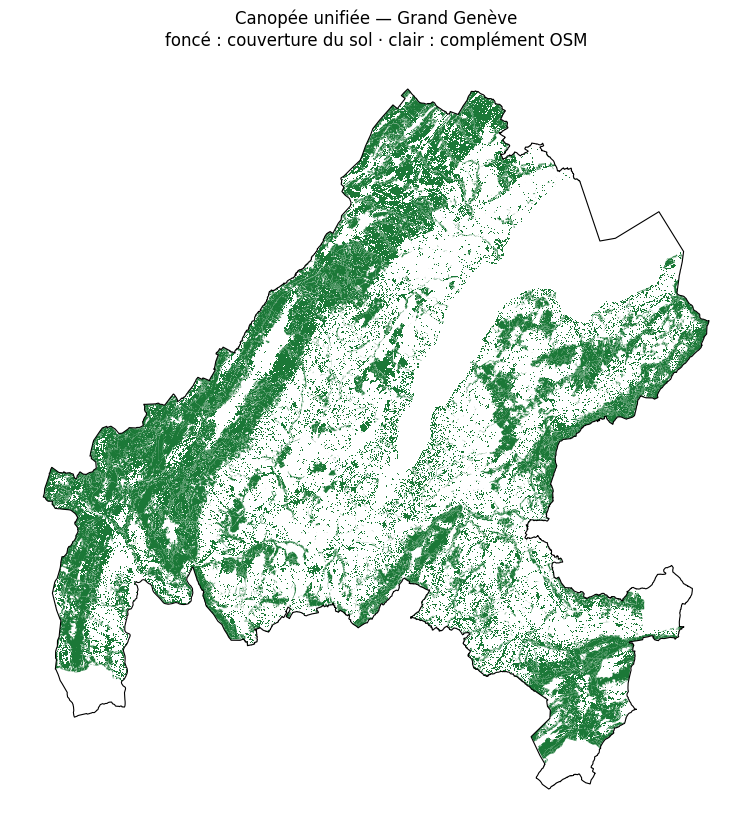

In [20]:
fig, ax = plt.subplots(figsize=(10, 10))
gpd.GeoSeries([perimeter], crs=WORK_CRS).boundary.plot(ax=ax, color="black", linewidth=0.8)
couv.plot(ax=ax, color="#1b7837", linewidth=0, label="couverture du sol")
# osm_ext.plot(ax=ax, color="#a6dba0", linewidth=0, label="complément OSM")
ax.set_title("Canopée unifiée — Grand Genève\nfoncé : couverture du sol · clair : complément OSM")
ax.set_axis_off()
plt.show()

## Mention de source

Conformément aux CGU du SITG (art. 9), toute publication d'un produit dérivé
doit porter une mention du type :

> Infographie réalisée sur la base de données issues du Système d'information
> du territoire à Genève (SITG), extrait en date du 31.03.2025 ; © les
> contributeurs OpenStreetMap (ODbL).

La partie OSM est sous licence ODbL : une couche dérivée combinant OSM et
d'autres données, si elle est diffusée, relève de l'obligation de partage à
l'identique de l'ODbL pour la partie issue d'OSM.